# Multinomial Logistic Regression Error Analysis

## Brain Connectivity Classification: Limitations and the Case for Alternative Approaches

This notebook analyzes the error patterns of multinomial logistic regression applied to brain region classification using functional connectivity fingerprints (232 regions). The analysis reveals fundamental limitations of the multinomial approach that motivate the use of **One-vs-Rest (OvR)** and **One-vs-One (OvO)** strategies.

### Key Research Questions
1. How does multinomial classification perform across 232 brain regions?
2. What error patterns emerge in rest vs. task conditions?
3. What are the structural limitations of multinomial for high-dimensional multi-class problems?

### Notebook Structure
1. **Setup & Data Loading** - Environment configuration and data import
2. **Model Performance Overview** - Cross-validation and task transfer accuracy
3. **Network-Level Error Analysis** - Error distribution across functional networks
4. **Hemisphere Confusion Analysis** - Within vs. cross-hemisphere errors
5. **Confusion Flow Visualization** - Sankey diagrams of error pathways
6. **Regional Error Patterns** - Fine-grained error analysis
7. **Limitations Summary** - Evidence for OvR/OvO approaches

---
## 1. Setup & Data Loading

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import json
from pathlib import Path
import warnings

# Statistical Analysis
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Path Configuration
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'

# Directory Setup for Each Model
full_multi_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'multinomial'
LH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'multinomial'
RH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'multinomial'

full_task_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'task_testing'
LH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'task_testing_multinomial'
RH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'task_testing_multinomial'

print(f"Results Directory: {RESULTS_DIR}")

Results Directory: /home/sjoon/projects/brain_connectivity_classifier/data/results


In [3]:
# Helper Functions
def load_json(filepath):
    """Load JSON file safely"""
    with open(filepath, 'r') as f:
        return json.load(f)

def load_npy(filepath):
    """Load numpy file safely"""
    return np.load(filepath, allow_pickle=True)

def load_csv(filepath):
    """Load CSV file safely"""
    return pd.read_csv(filepath)

def load_bundle(m_dir, t_dir):
    """Load standard file patterns from directories."""
    return [
        load_json(m_dir / 'overall_metrics.json'), 
        load_json(m_dir / 'fold_metrics.json'),
        load_csv(m_dir / 'network_metrics.csv'), 
        load_csv(m_dir / 'per_region_metrics.csv'),
        load_npy(m_dir / 'confusion_matrix.npy'), 
        load_npy(m_dir / 'cv_predictions.npy'),
        load_npy(m_dir / 'cv_probabilities.npy'), 
        load_npy(m_dir / 'cv_true_labels.npy'),
        load_npy(m_dir / 'cv_fold_indices.npy'), 
        load_json(t_dir / 'task_testing_summary.json'),
        load_csv(t_dir / 'task_network_metrics.csv'), 
        load_csv(t_dir / 'task_per_region_metrics.csv'),
        load_npy(t_dir / 'task_confusion_matrix.npy'), 
        load_npy(t_dir / 'task_predictions.npy'),
        load_npy(t_dir / 'task_probabilities.npy'), 
        load_npy(t_dir / 'task_true_labels.npy')
    ]

print("✓ Helper functions loaded")

✓ Helper functions loaded


In [4]:
# Load All Data

# Full Connectivity Model (232 regions)
overall_metrics_full, fold_metrics_full, network_metrics_cv_full, per_region_metrics_cv_full, \
confusion_matrix_cv_full, cv_predictions_full, cv_probabilities_full, cv_true_labels_full, \
cv_fold_indices_full, task_summary_full, network_metrics_task_full, per_region_metrics_task_full, \
confusion_matrix_task_full, task_predictions_full, task_probabilities_full, task_true_labels_full = load_bundle(full_multi_dir, full_task_dir)

region_info_full = load_csv(full_multi_dir / 'region_info.csv')

# Left Hemisphere Model (116 regions)
overall_metrics_lh, fold_metrics_lh, network_metrics_cv_lh, per_region_metrics_cv_lh, \
confusion_matrix_cv_lh, cv_predictions_lh, cv_probabilities_lh, cv_true_labels_lh, \
cv_fold_indices_lh, task_summary_lh, network_metrics_task_lh, per_region_metrics_task_lh, \
confusion_matrix_task_lh, task_predictions_lh, task_probabilities_lh, task_true_labels_lh = load_bundle(LH_multi_dir, LH_task_dir)

region_info_lh = region_info_full[region_info_full['hemisphere'] == 'left'].copy().assign(region_idx=lambda x: range(len(x)))

# Right Hemisphere Model (116 regions)
overall_metrics_rh, fold_metrics_rh, network_metrics_cv_rh, per_region_metrics_cv_rh, \
confusion_matrix_cv_rh, cv_predictions_rh, cv_probabilities_rh, cv_true_labels_rh, \
cv_fold_indices_rh, task_summary_rh, network_metrics_task_rh, per_region_metrics_task_rh, \
confusion_matrix_task_rh, task_predictions_rh, task_probabilities_rh, task_true_labels_rh = load_bundle(RH_multi_dir, RH_task_dir)

region_info_rh = region_info_full[region_info_full['hemisphere'] == 'right'].copy().assign(region_idx=lambda x: range(len(x)))

print("✓ All data loaded successfully")

✓ All data loaded successfully


---
## 2. Model Performance Overview

We compare three multinomial models to understand baseline performance before analyzing error patterns.

In [99]:
import pandas as pd
import numpy as np

# 1. DEFINE THE MODELS LIST
# Standardized as: (Name, Metrics, Task_Summary, Region_Info, CV_Preds, Task_Preds, CM)
models = [
    ('Full (232)', overall_metrics_full, task_summary_full, region_info_full, cv_predictions_full, task_predictions_full, confusion_matrix_cv_full),
    ('Left (116)', overall_metrics_lh, task_summary_lh, region_info_lh, cv_predictions_lh, task_predictions_lh, confusion_matrix_cv_lh),
    ('Right (116)', overall_metrics_rh, task_summary_rh, region_info_rh, cv_predictions_rh, task_predictions_rh, confusion_matrix_cv_rh)
]

# 2. CALCULATE POOLED METRICS FOR COMBINED (L+R)
# CV (Resting State) Pooled Counts
left_cv_total = len(cv_predictions_lh)
right_cv_total = len(cv_predictions_rh)
left_cv_correct = int(overall_metrics_lh['accuracy'] * left_cv_total)
right_cv_correct = int(overall_metrics_rh['accuracy'] * right_cv_total)

combined_cv_total = left_cv_total + right_cv_total
combined_cv_correct = left_cv_correct + right_cv_correct
combined_cv_acc = combined_cv_correct / combined_cv_total

# Task Pooled Counts
left_task_total = len(task_predictions_lh)
right_task_total = len(task_predictions_rh)
left_task_correct = int(task_summary_lh['task_test_accuracy'] * left_task_total)
right_task_correct = int(task_summary_rh['task_test_accuracy'] * right_task_total)

combined_task_total = left_task_total + right_task_total
combined_task_correct = left_task_correct + right_task_correct
combined_task_acc = combined_task_correct / combined_task_total

# Training Baseline (Averaged across hemispheres)
combined_rest_train = (task_summary_lh['rest_train_accuracy'] + task_summary_rh['rest_train_accuracy']) / 2

# Drop and Generalization logic
# BASELINE CHANGE: Drop is now (Rest_Train_Acc - Task_Accuracy)
combined_drop = combined_rest_train - combined_task_acc 
combined_gen = combined_task_acc / combined_cv_acc

# 3. BUILD THE COMPARISON DATAFRAME
rows = []

# Individual Model Rows
for m_name, m_metrics, m_task, m_regions, m_cv_p, m_task_p, m_cm in models:
    train_acc = m_task['rest_train_accuracy']
    task_acc = m_task['task_test_accuracy']
    cv_acc = m_metrics['accuracy']
    
    rows.append({
        'Model': m_name,
        'CV_Accuracy': f"{cv_acc:.4f}",
        'CV_Correct': int(cv_acc * len(m_cv_p)),
        'CV_Total': len(m_cv_p),
        'Rest_Train_Acc': f"{train_acc:.4f}",
        'Task_Accuracy': f"{task_acc:.4f}",
        'Task_Correct': int(task_acc * len(m_task_p)),
        'Task_Total': len(m_task_p),
        'Accuracy_Drop': f"{(train_acc - task_acc):.4f}", # BASELINE CORRECTED
        'Drop_Absolute': int((train_acc - task_acc) * len(m_task_p)),
        'Generalization': f"{(task_acc / cv_acc):.4f}",
        'N_Regions': len(m_regions),
        'CM_Shape': f"{m_cm.shape[0]}×{m_cm.shape[1]}"
    })

# Add the Combined (L+R) Row
rows.append({
    'Model': 'Combined (L+R)',
    'CV_Accuracy': f"{combined_cv_acc:.4f}",
    'CV_Correct': combined_cv_correct,
    'CV_Total': combined_cv_total,
    'Rest_Train_Acc': f"{combined_rest_train:.4f}",
    'Task_Accuracy': f"{combined_task_acc:.4f}",
    'Task_Correct': combined_task_correct,
    'Task_Total': combined_task_total,
    'Accuracy_Drop': f"{combined_drop:.4f}", # BASELINE CORRECTED
    'Drop_Absolute': int(combined_drop * combined_task_total),
    'Generalization': f"{combined_gen:.4f}",
    'N_Regions': '232 (116+116)',
    'CM_Shape': '116×116 each'
})

comparison_df = pd.DataFrame(rows)

# 4. OUTPUT SUMMARY
print("="*130)
print("MODEL COMPARISON SUMMARY: TRAINING BASELINE VS. TASK TESTING")
print("="*130)
print(comparison_df.to_string(index=False))

print("\n" + "="*130)
print("INTERPRETATION OF ACCURACY DROP:")
print("="*130)
print(f"• Baseline: Rest_Train_Accuracy (Ideal intrinsic learning)")
print(f"• Full (232) Drop:     {float(comparison_df.iloc[0]['Accuracy_Drop'])*100:.2f}%")
print(f"• Combined (L+R) Drop: {float(comparison_df.iloc[3]['Accuracy_Drop'])*100:.2f}%")
print(f"• Stability Advantage: { (float(comparison_df.iloc[3]['Accuracy_Drop']) - float(comparison_df.iloc[0]['Accuracy_Drop']))*100:.2f}%")
print("  (The Full model is more stable due to the inclusion of cross-hemispheric features)")
print("="*130)

MODEL COMPARISON SUMMARY: TRAINING BASELINE VS. TASK TESTING
         Model CV_Accuracy  CV_Correct  CV_Total Rest_Train_Acc Task_Accuracy  Task_Correct  Task_Total Accuracy_Drop  Drop_Absolute Generalization     N_Regions     CM_Shape
    Full (232)      0.9241       48025     51968         0.9902        0.8924         41407       46400        0.0978           4538         0.9657           232      232×232
    Left (116)      0.9182       23858     25984         0.9773        0.8693         20168       23200        0.1080           2506         0.9468           116      116×116
   Right (116)      0.9136       23738     25984         0.9774        0.8631         20023       23200        0.1143           2651         0.9447           116      116×116
Combined (L+R)      0.9159       47596     51968         0.9774        0.8662         40191       46400        0.1112           5158         0.9458 232 (116+116) 116×116 each

INTERPRETATION OF ACCURACY DROP:
• Baseline: Rest_Train_Accurac

---
## 3. Network Distribution Analysis

Understanding the hierarchical network structure (33 fine-grained networks → 8 major networks) provides context for interpreting error patterns.

In [6]:
# 8-Network Grouping Mapping (Yeo-7 + Subcortical)
network_to_major = {
    'VisCent': 'Visual', 'VisPeri': 'Visual',
    'SomMotA': 'Somatomotor', 'SomMotB': 'Somatomotor',
    'DorsAttnA': 'Dorsal Attention', 'DorsAttnB': 'Dorsal Attention',
    'SalVentAttnA': 'Salience/Ventral Attention', 'SalVentAttnB': 'Salience/Ventral Attention',
    'LimbicA': 'Limbic', 'LimbicB': 'Limbic',
    'ContA': 'Control', 'ContB': 'Control', 'ContC': 'Control',
    'DefaultA': 'Default', 'DefaultB': 'Default', 'DefaultC': 'Default',
    'TempPar': 'Default',
    'Hippocampus_ant': 'Subcortical', 'Hippocampus_post': 'Subcortical',
    'Amygdala_lat': 'Subcortical', 'Amygdala_med': 'Subcortical',
    'Thalamus_DA': 'Subcortical', 'Thalamus_DP': 'Subcortical',
    'Thalamus_VA': 'Subcortical', 'Thalamus_VP': 'Subcortical',
    'Caudate_ant': 'Subcortical', 'Caudate_post': 'Subcortical',
    'Putamen_ant': 'Subcortical', 'Putamen_post': 'Subcortical',
    'Pallidum_ant': 'Subcortical', 'Pallidum_post': 'Subcortical',
    'Accumbens_core': 'Subcortical', 'Accumbens_shell': 'Subcortical'
}

# Apply mapping to all region info DataFrames
for df in [region_info_full, region_info_lh, region_info_rh]:
    df['major_network'] = df['network'].map(network_to_major)

# Display network distribution
print("="*80)
print("MAJOR NETWORK DISTRIBUTION (8 Networks)")
print("="*80)

major_counts = region_info_full.groupby('major_network').size().reset_index(name='Full_Model')
major_counts['Left_Hemi'] = region_info_lh.groupby('major_network').size().values
major_counts['Right_Hemi'] = region_info_rh.groupby('major_network').size().values
major_counts['% of Total'] = (major_counts['Full_Model'] / 232 * 100).round(1)

print(f"\n{major_counts.to_string(index=False)}")

MAJOR NETWORK DISTRIBUTION (8 Networks)

             major_network  Full_Model  Left_Hemi  Right_Hemi  % of Total
                   Control          37         18          19        15.9
                   Default          43         26          17        18.5
          Dorsal Attention          22         11          11         9.5
                    Limbic          14          6           8         6.0
Salience/Ventral Attention          26         11          15        11.2
               Somatomotor          34         16          18        14.7
               Subcortical          32         16          16        13.8
                    Visual          24         12          12        10.3


---
## 4. Error Source Analysis

This section examines the **types** of classification errors to understand *where* the multinomial model struggles.

### Error Categories:
- **Within-Region**: Same hemisphere AND same network (fine-grained confusion)
- **Network-Only**: Same hemisphere, different network
- **Hemisphere-Only**: Different hemisphere, same network  
- **Both Wrong**: Different hemisphere AND different network

In [7]:
def analyze_errors_comprehensive(true_labels, pred_labels, region_info_df, strategy_name, data_type):
    """Analyze classification errors by hemisphere and network confusion types."""
    err_mask = true_labels != pred_labels
    total_samples, total_err = len(true_labels), err_mask.sum()
    
    fmt = lambda c: f"{c} ({(c / total_err * 100 if total_err > 0 else 0):.1f}%)"

    if total_err == 0:
        return [strategy_name, data_type, 0, "0.00%", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"]

    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({'true_idx': true_labels[err_mask], 'pred_idx': pred_labels[err_mask]})
    
    for col, attr in [('true_net', 'network'), ('pred_net', 'network'), 
                      ('true_hemi', 'hemisphere'), ('pred_hemi', 'hemisphere')]:
        df[col] = df['true_idx' if 'true' in col else 'pred_idx'].map(lookup[attr])

    s_h, s_n = (df['true_hemi'] == df['pred_hemi']), (df['true_net'] == df['pred_net'])

    return [
        strategy_name, data_type, total_err, f"{(total_err / total_samples) * 100:.2f}%",
        fmt((s_h & s_n).sum()), fmt((s_h & ~s_n).sum()), fmt((~s_h & s_n).sum()), fmt((~s_h & ~s_n).sum())
    ]

# Configure analyses
configs = [
    (cv_true_labels_full, cv_predictions_full, region_info_full, "Full", "Rest"),
    (task_true_labels_full, task_predictions_full, region_info_full, "Full", "Task"),
    (cv_true_labels_lh, cv_predictions_lh, region_info_lh, "LH_Hemi", "Rest"),
    (task_true_labels_lh, task_predictions_lh, region_info_lh, "LH_Hemi", "Task"),
    (cv_true_labels_rh, cv_predictions_rh, region_info_rh, "RH_Hemi", "Rest"),
    (task_true_labels_rh, task_predictions_rh, region_info_rh, "RH_Hemi", "Task")
]

# Process and display
error_comparison_table = [analyze_errors_comprehensive(*c) for c in configs]
columns = ["Model", "Data", "Total_Err", "Err_Rate", "Within_Reg", "Net_Only", "Hemi_Only", "Both_Wrong"]
error_df = pd.DataFrame(error_comparison_table, columns=columns)

print("="*100)
print("ERROR SOURCE COMPARISON: Multinomial Classification")
print("="*100)
print(error_df.to_string(index=False))
print("\n" + "="*100)
print("KEY FINDING: ~44-45% of Full model errors involve BOTH hemisphere AND network confusion.")
print("This indicates the multinomial struggles with the joint classification problem.")
print("="*100)

ERROR SOURCE COMPARISON: Multinomial Classification
  Model Data  Total_Err Err_Rate Within_Reg     Net_Only  Hemi_Only   Both_Wrong
   Full Rest       3943    7.59% 167 (4.2%) 1744 (44.2%) 284 (7.2%) 1748 (44.3%)
   Full Task       4993   10.76% 244 (4.9%) 2292 (45.9%) 325 (6.5%) 2132 (42.7%)
LH_Hemi Rest       2126    8.18% 178 (8.4%) 1948 (91.6%)   0 (0.0%)     0 (0.0%)
LH_Hemi Task       3032   13.07% 236 (7.8%) 2796 (92.2%)   0 (0.0%)     0 (0.0%)
RH_Hemi Rest       2246    8.64% 163 (7.3%) 2083 (92.7%)   0 (0.0%)     0 (0.0%)
RH_Hemi Task       3177   13.69% 210 (6.6%) 2967 (93.4%)   0 (0.0%)     0 (0.0%)

KEY FINDING: ~44-45% of Full model errors involve BOTH hemisphere AND network confusion.
This indicates the multinomial struggles with the joint classification problem.


---
## 5. Error Source Visualization

Visual comparison of error types across models and conditions.

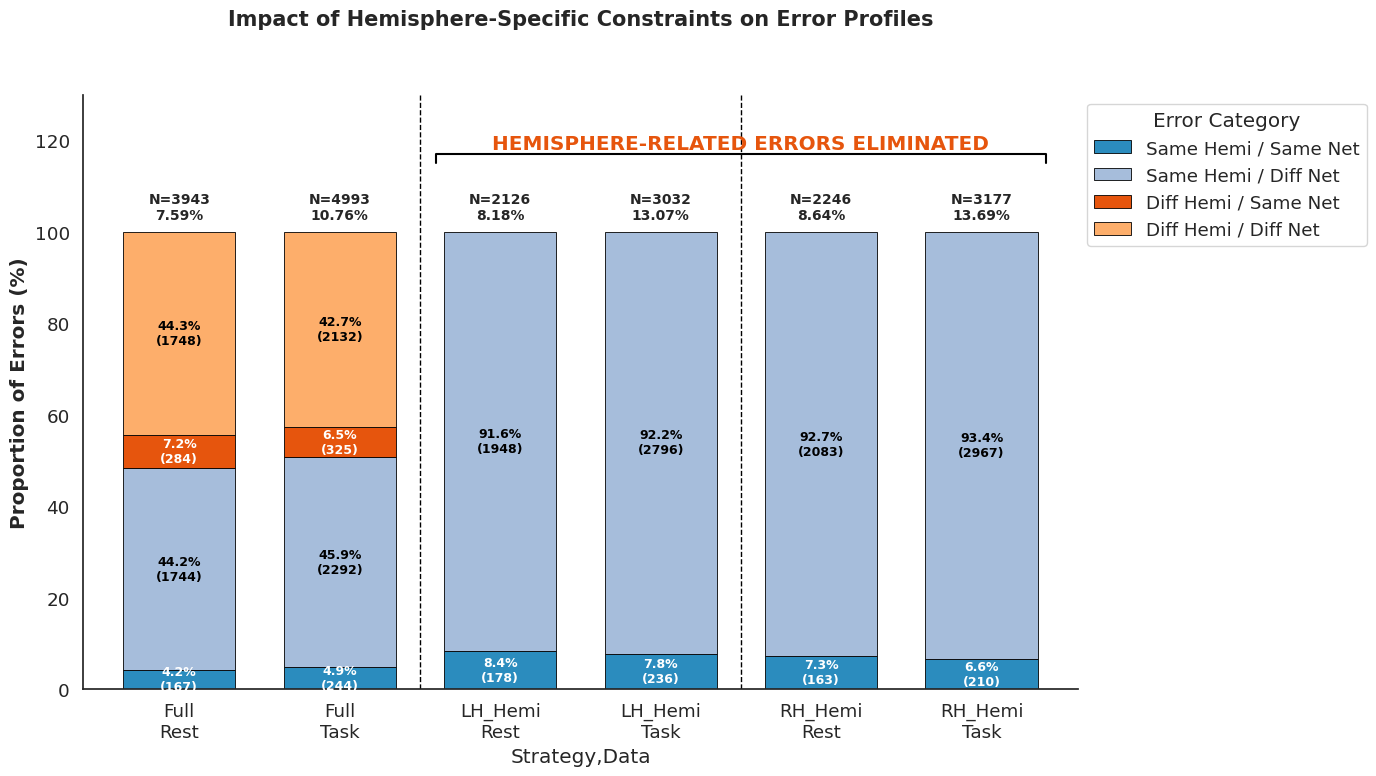

In [8]:
# 1. Clean and Parse Data
df = error_df.copy()
df.columns = ["Strategy", "Data", "N", "Rate", "SH_SN", "SH_DN", "DH_SN", "DH_DN"]

# Extract counts and percentages from strings like "167 (4.2%)"
cols_to_parse = ["SH_SN", "SH_DN", "DH_SN", "DH_DN"]
for col in cols_to_parse:
    df[[f"{col}_count", f"{col}_pct"]] = df[col].str.extract(r'(\d+) \(([\d.]+)%\)').astype(float)

# 2. Setup Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# Colors: Blues (Same Hemi), Oranges (Diff Hemi)
colors = ['#2b8cbe', '#a6bddb', '#e6550d', '#fdae6b']
labels = ["Same Hemi / Same Net", "Same Hemi / Diff Net", "Diff Hemi / Same Net", "Diff Hemi / Diff Net"]

# 3. Plot Stacked Bars
pct_cols = [f"{c}_pct" for c in cols_to_parse]
df_plot = df.set_index(['Strategy', 'Data'])[pct_cols]
df_plot.columns = labels
df_plot.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.7, edgecolor='black', linewidth=0.6)

# 4. Annotations
for i, (idx, row) in enumerate(df.iterrows()):
    cum_height = 0
    for j, col in enumerate(cols_to_parse):
        pct, count = row[f"{col}_pct"], int(row[f"{col}_count"])
        if pct > 2.0:  # Only label if visible
            ax.text(i, cum_height + (pct/2), f"{pct:.1f}%\n({count})", 
                    ha='center', va='center', color="white" if j in [0, 2] else "black", 
                    fontsize=9, fontweight='bold')
        cum_height += pct
    
    # Header labels (N and Rate)
    ax.text(i, 102, f"N={int(row['N'])}\n{row['Rate']}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Visual Callouts & Polish
[ax.axvline(x, color='black', ls='--', lw=1) for x in [1.5, 3.5]]

# Bracket for Hemisphere-specific models
ax.plot([1.6, 1.6, 5.4, 5.4], [115, 117, 117, 115], color="black", lw=1.5)
ax.text(3.5, 118, "HEMISPHERE-RELATED ERRORS ELIMINATED", ha='center', fontweight='bold', color='#e6550d')

ax.set_ylabel("Proportion of Errors (%)", fontweight='bold')
ax.set_title("Impact of Hemisphere-Specific Constraints on Error Profiles", fontsize=15, pad=50, fontweight='bold')
ax.set_xticklabels([f"{s}\n{d}" for s, d in df_plot.index], rotation=0)
ax.set_ylim(0, 130)
ax.legend(title="Error Category", bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

---
## 6. Network-Level Confusion Analysis

Examining which networks are most confused with each other reveals systematic patterns.

In [9]:
def build_network_confusion_matrix(true_labels, pred_labels, region_info_df, use_major=True):
    """Build confusion matrix at the network level."""
    lookup = region_info_df.set_index('region_idx')
    net_col = 'major_network' if use_major else 'network'
    
    true_nets = pd.Series(true_labels).map(lookup[net_col])
    pred_nets = pd.Series(pred_labels).map(lookup[net_col])
    
    networks = sorted(true_nets.unique())
    cm = confusion_matrix(true_nets, pred_nets, labels=networks)
    
    return cm, networks

# Build matrices for rest and task
cm_rest, networks = build_network_confusion_matrix(cv_true_labels_full, cv_predictions_full, region_info_full)
cm_task, _ = build_network_confusion_matrix(task_true_labels_full, task_predictions_full, region_info_full)

# Normalize to show error rates (off-diagonal only)
def normalize_cm_errors(cm):
    """Normalize confusion matrix and zero the diagonal."""
    cm_float = cm.astype(float)
    row_sums = cm_float.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_float, row_sums, where=row_sums != 0) * 100
    np.fill_diagonal(cm_norm, np.nan)  # Hide correct classifications
    return cm_norm

cm_rest_norm = normalize_cm_errors(cm_rest)
cm_task_norm = normalize_cm_errors(cm_task)

In [10]:

# Networks 
# 1. Networks and Setup
networks = [
    'Visual', 'Somatomotor', 'Dorsal Attention', 'Salience/Ventral Attention',
    'Limbic', 'Control', 'Default', 'Subcortical'
]
rows = ['Full', 'Left', 'Right']
cols = ['Rest (CV)', 'Task (Test)', 'Difference (T-R)']

def aggregate_to_network_sum(region_matrix, region_info):
    net_labels = region_info['major_network'].values
    df = pd.DataFrame(region_matrix, index=net_labels, columns=net_labels)
    
    # Use .sum() to preserve absolute counts
    row_grouped = df.groupby(level=0).sum()
    full_grouped = row_grouped.transpose().groupby(level=0).sum().transpose()
    
    net_matrix = full_grouped.reindex(index=networks, columns=networks).fillna(0)
    return net_matrix.values

# 3. Process matrices for Absolute Counts
full_rest_net = aggregate_to_network_sum(confusion_matrix_cv_full, region_info_full)
full_task_net = aggregate_to_network_sum(confusion_matrix_task_full, region_info_full)
lh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_lh, region_info_lh)
lh_task_net = aggregate_to_network_sum(confusion_matrix_task_lh, region_info_lh)
rh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_rh, region_info_rh)
rh_task_net = aggregate_to_network_sum(confusion_matrix_task_rh, region_info_rh)

# 4. Organize for Plotting
matrix_data = [
    [full_rest_net, full_task_net, (full_task_net - full_rest_net)],
    [lh_rest_net,   lh_task_net,   (lh_task_net - lh_rest_net)],
    [rh_rest_net,   rh_task_net,   (rh_task_net - rh_rest_net)]
]
# 1. Colors from the Bar Chart theme
color_blue = '#2b8cbe'
color_orange = '#e6550d'

# 2. Define Custom Colorscales
colorscale_seq = [[0, '#f7fbff'], [1, color_blue]] 
colorscale_div = [[0, color_blue], [0.5, '#ffffff'], [1, color_orange]]

# 3. Create Heatmap Grid
# Increased vertical/horizontal spacing to prevent label overlap
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"<b>{r} Strategy: {c}</b>" for r in rows for c in cols],
    horizontal_spacing=0.12, 
    vertical_spacing=0.15
)

for i in range(3):
    for j in range(3):
        data = matrix_data[i][j].copy()
        mask = np.eye(len(networks), dtype=bool)
        data_masked = np.where(mask, None, data)
        
        if j < 2:
            colorscale = colorscale_seq
            zmin, zmax = 0, np.nanmax(data_masked[data_masked != None])
        else:
            colorscale = colorscale_div
            limit = np.nanmax(np.abs(data_masked[data_masked != None].astype(float)))
            zmin, zmax = -limit, limit

        fig.add_trace(
            go.Heatmap(
                z=data_masked,
                x=networks, 
                y=networks,
                colorscale=colorscale,
                zmin=zmin, 
                zmax=zmax,
                text=data_masked,
                texttemplate="%{text:.0f}",
                textfont={"size": 9},
                showscale=False,
                hovertemplate="True: %{y}<br>Predicted: %{x}<br>Value: %{z}<extra></extra>"
            ),
            row=i+1, col=j+1
        )

# 4. Final Layout Adjustments
fig.update_layout(
    title_text="<b>8-Network Absolute Off-Diagonal Error Counts </b>",
    template="plotly_white",
    height=1300, # Increased height to allow more room for x-labels
    width=1500,
    # Added explicit margins to prevent labels from cutting off at the edges
    margin=dict(l=150, r=50, t=150, b=150)
)

# 5. Prevent Overlap via tickangle and standoff
fig.update_xaxes(
    tickangle=45, 
    tickfont=dict(size=10),
    automargin=True # Automatically adjusts subplot size to fit labels
)

fig.update_yaxes(
    autorange="reversed", 
    tickfont=dict(size=10),
    automargin=True # Ensures network names don't overlap the y-axis
)

fig.show()

---
## 7. Sankey Flow Visualization

Sankey diagrams show the flow of classification errors from true networks through hemispheres to predicted networks.

In [11]:
import re
import pandas as pd
import plotly.graph_objects as go
def create_sankey_data(true_labels, pred_labels, region_info_df):

    """Extract error flows for Sankey diagram."""
    err_mask = true_labels != pred_labels
    lookup = region_info_df.set_index('region_idx')
    
    df = pd.DataFrame({
    'true_net': pd.Series(true_labels[err_mask]).map(lookup['major_network']),
    'pred_net': pd.Series(pred_labels[err_mask]).map(lookup['major_network']),
    'true_hemi': pd.Series(true_labels[err_mask]).map(lookup['hemisphere']),
    'pred_hemi': pd.Series(pred_labels[err_mask]).map(lookup['hemisphere'])
    })
    return df

import re
import pandas as pd
import plotly.graph_objects as go

# Network color mapping
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)',
    'Somatomotor': 'rgb(70, 130, 180)',
    'Dorsal Attention': 'rgb(0, 118, 14)',
    'Salience/Ventral Attention': 'rgb(196, 58, 250)',
    'Limbic': 'rgb(220, 248, 164)',
    'Control': 'rgb(230, 148, 34)',
    'Default': 'rgb(205, 62, 78)',
    'Subcortical': 'rgb(12, 123, 174)'
}

def to_rgba(color_str, alpha=0.3):
    """Safely converts rgb strings to rgba for transparency."""
    rgb = re.findall(r'\d+', color_str)
    if len(rgb) >= 3:
        return f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha})'
    return color_str

def build_publication_sankey(df, title):
    # 1. Setup Labels & Base Logic
    networks = sorted(df['true_net'].unique())
    n_nets = len(networks)
    
    # Node Order: True Nets (0-7) -> True Hemi (8,9) -> Pred Hemi (10,11) -> Pred Nets (12-19)
    node_labels = networks + ['Left', 'Right'] + ['Left', 'Right'] + networks
    node_colors = [NETWORK_COLORS.get(n, 'gray') for n in networks] + \
                  ['#505050']*4 + \
                  [NETWORK_COLORS.get(n, 'gray') for n in networks]

    # 2. Manual Positioning (0=Left, 1=Right for x; 0=Top, 1=Bottom for y)
    x_pos = [0.01]*n_nets + [0.33, 0.33] + [0.66, 0.66] + [0.99]*n_nets
    
    # Generate even y-spacing for networks, but fixed y for hemispheres
    net_y = [i / (n_nets - 1) for i in range(n_nets)]
    # Hemi y: Left at 0.2 (top-ish), Right at 0.8 (bottom-ish)
    y_pos = net_y + [0.2, 0.8] + [0.2, 0.8] + net_y

    sources, targets, values, link_colors = [], [], [], []

    # 3. Flow Logic
    # Layer 1: True Net -> True Hemi
    for i, net in enumerate(networks):
        for j, hemi in enumerate(['left', 'right']):
            count = len(df[(df['true_net'] == net) & (df['true_hemi'] == hemi)])
            if count > 0:
                sources.append(i)
                targets.append(n_nets + j)
                values.append(count)
                link_colors.append(to_rgba(NETWORK_COLORS.get(net), 0.3))

    # Layer 2: True Hemi -> Pred Hemi
    for i, th in enumerate(['left', 'right']):
        for j, ph in enumerate(['left', 'right']):
            count = len(df[(df['true_hemi'] == th) & (df['pred_hemi'] == ph)])
            if count > 0:
                sources.append(n_nets + i)
                targets.append(n_nets + 2 + j)
                values.append(count)
                link_colors.append('rgba(211, 211, 211, 0.4)')

    # Layer 3: Pred Hemi -> Pred Net
    for i, hemi in enumerate(['left', 'right']):
        for j, net in enumerate(networks):
            count = len(df[(df['pred_hemi'] == hemi) & (df['pred_net'] == net)])
            if count > 0:
                sources.append(n_nets + 2 + i)
                targets.append(n_nets + 4 + j)
                values.append(count)
                link_colors.append(to_rgba(NETWORK_COLORS.get(net), 0.3))

    fig = go.Figure(go.Sankey(
        arrangement = "fixed", # Necessary for manual x/y to work
        node=dict(
            label=[l.upper() for l in node_labels],
            color=node_colors,
            x=x_pos,
            y=y_pos,
            pad=30, thickness=20,
            line=dict(color="white", width=1)
        ),
        link=dict(
            source=sources, target=targets, value=values, color=link_colors,
            hovertemplate='<b>%{source.label} → %{target.label}</b><br>Count: %{value}<extra></extra>'
        )
    ))

    fig.update_layout(
        title=dict(text=f"<b>{title}</b>", x=0.5, font=dict(size=22, family="Arial", color='black')),
        width=1100, height=800,
        margin=dict(t=140, b=40, l=60, r=60),
        font=dict(family="Arial", size=13),
        plot_bgcolor='white',
        paper_bgcolor='white',
        annotations=[
            dict(x=0, y=1.1, text='<b>TRUE NETWORK</b>', showarrow=False, xref='paper', yref='paper', font=dict(size=14)),
            dict(x=0.33, y=1.1, text='<b>TRUE HEMI</b>', showarrow=False, xref='paper', yref='paper', font=dict(size=14)),
            dict(x=0.67, y=1.1, text='<b>PRED HEMI</b>', showarrow=False, xref='paper', yref='paper', font=dict(size=14)),
            dict(x=1, y=1.1, text='<b>PRED NETWORK</b>', showarrow=False, xref='paper', yref='paper', font=dict(size=14))
        ]
    )
    return fig
# Execute
df_rest = create_sankey_data(cv_true_labels_full, cv_predictions_full, region_info_full)
fig_rest = build_publication_sankey(df_rest, 'Error Flow: Rest (CV) - Full Model')
fig_rest.show()

---
## 8. Rest vs Task Error Change Analysis

Examining how error patterns shift from rest to task reveals functional reorganization.

In [43]:
# Calculate network-level error rates
def get_network_error_rates(true_labels, pred_labels, region_info_df):
    """Calculate error rate per network."""
    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({
        'true_net': pd.Series(true_labels).map(lookup['major_network']),
        'correct': true_labels == pred_labels
    })
    
    return df.groupby('true_net').agg(
        total=('correct', 'count'),
        errors=('correct', lambda x: (~x).sum())
    ).assign(error_rate=lambda x: x['errors'] / x['total'])

rest_rates_full = get_network_error_rates(cv_true_labels_full, cv_predictions_full, region_info_full)
task_rates_full = get_network_error_rates(task_true_labels_full, task_predictions_full, region_info_full)

# left hemisphere
rest_rates_lh = get_network_error_rates(cv_true_labels_lh, cv_predictions_lh, region_info_lh)
task_rates_lh = get_network_error_rates(task_true_labels_lh, task_predictions_lh, region_info_lh)

# right hemisphere
rest_rates_rh = get_network_error_rates(cv_true_labels_rh, cv_predictions_rh, region_info_rh)
task_rates_rh = get_network_error_rates(task_true_labels_rh, task_predictions_rh, region_info_rh)

# Combine and calculate change for left hemisphere
comparison_left = pd.DataFrame({
    'Network': rest_rates_lh.index,
    'Rest_Error_Rate': rest_rates_lh['error_rate'].values,
    'Task_Error_Rate': task_rates_lh['error_rate'].values
}).assign(
    Change=lambda x: x['Task_Error_Rate'] - x['Rest_Error_Rate'],
    Pct_Change=lambda x: ((x['Task_Error_Rate'] - x['Rest_Error_Rate']) / x['Rest_Error_Rate'] * 100)
).sort_values('Change', ascending=False)

# Combine and calculate change for right hemisphere
comparison_right = pd.DataFrame({
    'Network': rest_rates_rh.index,
    'Rest_Error_Rate': rest_rates_rh['error_rate'].values,
    'Task_Error_Rate': task_rates_rh['error_rate'].values
}).assign(
    Change=lambda x: x['Task_Error_Rate'] - x['Rest_Error_Rate'],
    Pct_Change=lambda x: ((x['Task_Error_Rate'] - x['Rest_Error_Rate']) / x['Rest_Error_Rate'] * 100)
).sort_values('Change', ascending=False)

print("="*80)
print("NETWORK ERROR RATE CHANGE: Rest → Task")
print("="*80)

print("\nLeft Hemisphere Model")
print("-"*80)
print(comparison_left.to_string(index=False))

print("\nRight Hemisphere Model")
print("-"*80)
print(comparison_right.to_string(index=False))


print("\nPositive change = more errors during task")

NETWORK ERROR RATE CHANGE: Rest → Task

Left Hemisphere Model
--------------------------------------------------------------------------------
                   Network  Rest_Error_Rate  Task_Error_Rate   Change  Pct_Change
               Subcortical         0.188616         0.317500 0.128884   68.331361
Salience/Ventral Attention         0.048701         0.101818 0.053117  109.066667
               Somatomotor         0.049386         0.095625 0.046239   93.627119
                   Control         0.074901         0.115000 0.040099   53.536424
                   Default         0.060268         0.099615 0.039348   65.287749
                    Visual         0.042039         0.071667 0.029628   70.477876
                    Limbic         0.197173         0.213333 0.016161    8.196226
          Dorsal Attention         0.049513         0.057273 0.007760   15.672131

Right Hemisphere Model
--------------------------------------------------------------------------------
              

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# 1. Aggregate Hemispheres into a Single Network Value
def prepare_global_network_df(df_l_raw, df_r_raw, color_map):
    # Combine LH and RH raw data
    df_combined = pd.concat([df_l_raw, df_r_raw], ignore_index=True)
    
    # Calculate Mean Error Rates across both hemispheres for each network
    df_global = df_combined.groupby('Network').agg({
        'Rest_Error_Rate': 'mean',
        'Task_Error_Rate': 'mean'
    }).reset_index()
    
    # Rename for consistency
    df_global = df_global.rename(columns={
        'Rest_Error_Rate': 'Rest',
        'Task_Error_Rate': 'Task'
    })
    
    # Recalculate Deltas and Percent Changes
    df_global['Δ'] = df_global['Task'] - df_global['Rest']
    df_global['Pct_Change'] = (df_global['Δ'] / df_global['Rest']) * 100
    df_global['Color'] = df_global['Network'].map(color_map)
    
    # Sort by Task Error (Highest at top)
    return df_global.sort_values(by='Task', ascending=False).reset_index(drop=True)

# Define universal colors
colors = ['#444444', '#D4E157', '#BF5AF2', '#FF453A', '#FF9F0A', '#5E9ED6', '#1E824C', '#8E44AD']
networks = pd.concat([comparison_left['Network'], comparison_right['Network']]).unique()
color_map = {net: colors[i % len(colors)] for i, net in enumerate(networks)}

df_final = prepare_global_network_df(comparison_left, comparison_right, color_map)

# 2. Setup Plot
fig = go.Figure()

# 3. Label Spacing Logic
min_spacing = 0.012 
adjusted_y = df_final['Task'].tolist()
for i in range(1, len(adjusted_y)):
    if (adjusted_y[i-1] - adjusted_y[i]) < min_spacing:
        adjusted_y[i] = adjusted_y[i-1] - min_spacing

# 4. Add Traces (One line per Network)
for i, row in df_final.iterrows():
    fig.add_trace(go.Scatter(
        x=['Rest (Intrinsic)', 'Task (Evoked)'],
        y=[row['Rest'], row['Task']],
        mode='lines+markers',
        line=dict(color=row['Color'], width=3),
        marker=dict(size=10, color=row['Color']),
        showlegend=False,
        hoverinfo='skip'
    ))

    # Annotation for Task Side (Network + Task Value + Pct)
    pct_text = f"{round(row['Pct_Change'])}%"
    fig.add_annotation(
        x='Task (Evoked)', y=adjusted_y[i],
        text=f"<b>{row['Network']}</b><br>{row['Task']:.2f} ({pct_text})",
        showarrow=False, xanchor='left', xshift=15, align='left',
        font=dict(color=row['Color'], size=10, family="Arial")
    )

    # Annotation for Rest Side (Value only)
    fig.add_annotation(
        x='Rest (Intrinsic)', y=row['Rest'],
        text=f"{row['Rest']:.2f}",
        showarrow=False, xshift=-35,
        font=dict(color=row['Color'], size=9, family="Arial")
    )

# 5. Final Styling
fig.update_layout(
    template='simple_white',
    title={
        'text': "<b>Network-Level Shift Analysis: Global Error Rate Increase</b><br><sup>Combined average of Left and Right Hemispheres</sup>",
        'y': 0.95, 'x': 0.45, 'xanchor': 'center', 'font': dict(size=22)
    },
    height=850,
    width=1250,
    xaxis=dict(range=[-0.5, 2.5], showgrid=False, tickfont=dict(size=12, family="Arial Bold")),
    yaxis=dict(
        title="<b>Error Rate</b>",
        range=[0.0, 0.35],
        dtick=0.05,
        tickformat='.2f',
        showgrid=True,
        gridcolor='#EEEEEE',
        zeroline=True,
        zerolinecolor='black'
    ),
    margin=dict(l=100, r=280, t=120, b=100)
)

fig.show()



In [57]:
df_combined

,Network,Rest,Task,Δ (Task-Rest),Pct_Change,Hemi,Color
0,Subcortical,0.191406,0.345625,0.154219,80.571429,RH,#444444
1,Subcortical,0.188616,0.317500,0.128884,68.331361,LH,#444444
2,Limbic,0.197173,0.213333,0.016161,8.196226,LH,#1E824C
3,Limbic,0.142857,0.176250,0.033393,23.375000,RH,#1E824C
4,Salience/Ventral Attention,0.081845,0.132667,0.050821,62.094545,RH,#D4E157
5,Control,0.074901,0.115000,0.040099,53.536424,LH,#FF453A
6,Default,0.071166,0.112941,0.041775,58.701107,RH,#FF9F0A
7,Control,0.082002,0.109211,0.027209,33.180516,RH,#FF453A
8,Salience/Ventral Attention,0.048701,0.101818,0.053117,109.066667,LH,#D4E157
9,Default,0.060268,0.099615,0.039348,65.287749,LH,#FF9F0A


---
## 9. Regional Error Analysis

Drilling down to individual regions to identify the most problematic classifications.

In [51]:
# Calculate per-region error counts
def get_region_errors(true_labels, pred_labels, region_info_df):
    """Get error counts per region."""
    errors = pd.Series(true_labels[true_labels != pred_labels]).value_counts()
    total = pd.Series(true_labels).value_counts()
    
    result = region_info_df.copy()
    result['errors'] = result['region_idx'].map(errors).fillna(0).astype(int)
    result['total'] = result['region_idx'].map(total).fillna(0).astype(int)
    result['error_rate'] = result['errors'] / result['total']
    
    return result

rest_regions_full = get_region_errors(cv_true_labels_full, cv_predictions_full, region_info_full)
task_regions_full = get_region_errors(task_true_labels_full, task_predictions_full, region_info_full)

# Left hemisphere
rest_regions_lh = get_region_errors(cv_true_labels_lh, cv_predictions_lh, region_info_lh)
task_regions_lh = get_region_errors(task_true_labels_lh, task_predictions_lh, region_info_lh)

# Right hemisphere
rest_regions_rh = get_region_errors(cv_true_labels_rh, cv_predictions_rh, region_info_rh)
task_regions_rh = get_region_errors(task_true_labels_rh, task_predictions_rh, region_info_rh)

# Merge LH for comparison
region_comparison_LH = rest_regions_lh[['region_name', 'major_network', 'hemisphere', 'errors', 'error_rate']].rename(
    columns={'errors': 'rest_errors', 'error_rate': 'rest_rate'}
).merge(
    task_regions_lh[['region_name', 'errors', 'error_rate']].rename(
        columns={'errors': 'task_errors', 'error_rate': 'task_rate'}
    ), on='region_name'
).assign(
    error_change=lambda x: x['task_errors'] - x['rest_errors'],
    rate_change=lambda x: x['task_rate'] - x['rest_rate']
)

# Merge RH for comparison
region_comparison_RH = rest_regions_rh[['region_name', 'major_network', 'hemisphere', 'errors', 'error_rate']].rename(
    columns={'errors': 'rest_errors', 'error_rate': 'rest_rate'}
).merge(
    task_regions_rh[['region_name', 'errors', 'error_rate']].rename(
        columns={'errors': 'task_errors', 'error_rate': 'task_rate'}
    ), on='region_name'
).assign(
    error_change=lambda x: x['task_errors'] - x['rest_errors'],
    rate_change=lambda x: x['task_rate'] - x['rest_rate']
)



# Show top error-increasing regions
print("="*80)
print("TOP 15 REGIONS WITH LARGEST ERROR INCREASE (Rest → Task)")
print("="*80)
print(region_comparison_LH.nlargest(15, 'error_change')[[
    'region_name', 'major_network', 'hemisphere', 'rest_errors', 'task_errors', 'error_change'
]].to_string(index=False))

print("\n" + "="*80)
print("TOP 15 REGIONS WITH LARGEST ERROR INCREASE (Rest → Task)")
print("="*80)
print(region_comparison_RH.nlargest(15, 'error_change')[[
    'region_name', 'major_network', 'hemisphere', 'rest_errors', 'task_errors', 'error_change'
]].to_string(index=False))  

TOP 15 REGIONS WITH LARGEST ERROR INCREASE (Rest → Task)
       region_name major_network hemisphere  rest_errors  task_errors  error_change
         THA-VA-lh   Subcortical       left           40           92            52
            aGP-lh   Subcortical       left           99          138            39
            pGP-lh   Subcortical       left           83          114            31
   LH_SomMotB_S2_1   Somatomotor       left           12           42            30
       NAc-core-lh   Subcortical       left           18           48            30
  LH_SomMotB_Aud_3   Somatomotor       left           10           39            29
      NAc-shell-lh   Subcortical       left           30           58            28
           aPUT-lh   Subcortical       left           10           37            27
   LH_ContA_PFCl_2       Control       left           14           39            25
  LH_ContC_Cingp_1       Control       left            7           32            25
LH_DefaultB_Temp_3 

In [58]:
import plotly.graph_objects as go
import pandas as pd

# 1. Combine LH and RH data and calculate global means
def get_combined_accuracy(df_lh, df_rh):
    # Combine dataframes
    df_combined = pd.concat([df_lh, df_rh], ignore_index=True)
    
    # Calculate Mean error rates per Network across both hemispheres
    df_acc = df_combined.groupby('major_network')[['rest_rate', 'task_rate']].mean().reset_index()
    
    # Convert error rates to Accuracy (%)
    df_acc['Rest Accuracy (%)'] = (1 - df_acc['rest_rate']) * 100
    df_acc['Task Accuracy (%)'] = (1 - df_acc['task_rate']) * 100
    
    # Sort by Task Accuracy (%) descending for a clean hierarchy
    return df_acc.sort_values('Task Accuracy (%)', ascending=False)

# Process the combined data
df_acc_global = get_combined_accuracy(region_comparison_LH, region_comparison_RH)

# 2. Build the Unified Vertical Bar Plot
fig = go.Figure()

# Add Resting State Bar
fig.add_trace(go.Bar(
    x=df_acc_global['major_network'],
    y=df_acc_global['Rest Accuracy (%)'],
    name='Resting State',
    marker_color='rgba(31, 119, 180, 0.7)',
    marker_line=dict(width=1.5, color='rgb(31, 119, 180)'),
    text=df_acc_global['Rest Accuracy (%)'].round(1),
    textposition='outside',
    textfont=dict(size=10)
))

# Add Task-Based Bar
fig.add_trace(go.Bar(
    x=df_acc_global['major_network'],
    y=df_acc_global['Task Accuracy (%)'],
    name='Task-Based',
    marker_color='rgba(255, 127, 14, 0.7)',
    marker_line=dict(width=1.5, color='rgb(255, 127, 14)'),
    text=df_acc_global['Task Accuracy (%)'].round(1),
    textposition='outside',
    textfont=dict(size=10)
))

# 3. Academic Styling
fig.update_layout(
    template='simple_white',
    title={
        'text': '<b>Global Mean Classification Accuracy: Rest vs Task</b><br><sup>Combined Mean of Left and Right Hemispheres</sup>',
        'x': 0.5, 'y': 0.95,
        'font': dict(size=22, family="Arial")
    },
    xaxis_title='<b>Functional Network</b>',
    yaxis_title='<b>Accuracy (%)</b>',
    barmode='group',
    height=700, 
    width=1100,
    legend=dict(
        orientation="h", 
        yanchor="bottom", y=1.02, 
        xanchor="center", x=0.5,
        font=dict(size=12)
    ),
    font=dict(family="Arial", size=13),
    margin=dict(t=140, b=100, l=80, r=40)
)

# Y-Axis formatting with academic grid
fig.update_yaxes(
    range=[0, 115], 
    dtick=20, 
    showgrid=True, 
    gridcolor='lightgrey',
    zeroline=True,
    zerolinecolor='black'
)

# X-Axis formatting
fig.update_xaxes(tickangle=45)

fig.show()

In [59]:
import plotly.express as px

# 1. Prepare Data
region_comparison = pd.concat([region_comparison_LH, region_comparison_RH], ignore_index=True)

df_plot = region_comparison.melt(
    id_vars=['region_name', 'major_network'], 
    value_vars=['rest_rate', 'task_rate'],
    var_name='Condition', value_name='Error Rate'
).replace({'rest_rate': 'Resting State', 'task_rate': 'Task-Based'})

# 2. Generate Figure
fig = px.violin(
    df_plot,
    x='major_network', 
    y='Error Rate', 
    color='Condition',
    box=True, 
    points='all', # "all" is good for transparency, "outliers" is cleaner for large N
    category_orders={"Condition": ["Resting State", "Task-Based"]},
    color_discrete_map={'Resting State': '#1f77b4', 'Task-Based': '#ff7f0e'}
)

# 3. Academic Styling
fig.update_layout(
    template='simple_white', # Cleaner than plotly_white for journals
    height=600, 
    width=1000,
    font=dict(family="Arial", size=14, color="black"),
    title={
        'text': "<b>Figure 1.</b> Regional Error Rate Distribution Across Major Networks",
        'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    legend=dict(
        title="", # Removed for cleaner look
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=60, r=40, t=100, b=100)
)

# 4. Axis Refinement
fig.update_xaxes(
    title_text="<b>Major Network</b>", 
    tickangle=45,
    showline=True, 
    linewidth=1.5, 
    linecolor='black'
)

fig.update_yaxes(
    title_text="<b>Error Rate (%)</b>", 
    showgrid=True, 
    gridcolor='lightgrey',
    showline=True, 
    linewidth=1.5, 
    linecolor='black'
)

# 5. Violin Adjustments
fig.update_traces(
    meanline_visible=True,
    scalemode='width', # Ensures violins are comparable across networks
    marker=dict(size=3, opacity=0.5) # Smaller points prevent cluttering
)

fig.show()

In [60]:
import plotly.graph_objects as go
import numpy as np

# 1. Prepare Data
df = region_comparison.copy()
df['display_change'] = df['rate_change']

# Identify top outliers to label explicitly (e.g., top 10 regions with most task errors)
# This prevents 232 labels from overlapping
top_regions = df.nlargest(10, 'task_errors')['region_name'].tolist()

network_colors = {
    'Control': '#8dd3c7', 'Default': '#fb8072', 'Dorsal Attention': '#bebada',
    'Limbic': '#80b1d3', 'Salience/Ventral Attention': '#bc80bd',
    'Somatomotor': '#fdb462', 'Subcortical': '#404040', 'Visual': '#b3de69'
}

fig = go.Figure()

# 2. Background Shading and Identity Line
fig.add_shape(type="path", path="M 0,0 L 125,125 L 0,125 Z",
              fillcolor="rgba(255,0,0,0.02)", line_width=0, layer="below")
fig.add_shape(type="path", path="M 0,0 L 125,125 L 125,0 Z",
              fillcolor="rgba(0,255,0,0.02)", line_width=0, layer="below")

fig.add_trace(go.Scatter(
    x=[0, 125], y=[0, 125],
    mode='lines',
    line=dict(color='rgba(150,150,150,0.5)', width=1, dash='dash'),
    showlegend=False, hoverinfo='none'
))

# 3. Scatter Points with Selective Text Labels
jitter = 0.8 
for network in df['major_network'].unique():
    net_df = df[df['major_network'] == network].copy()
    
    # Logic to show text only for top regions to avoid overlap
    display_text = [name if name in top_regions else "" for name in net_df['region_name']]
    
    fig.add_trace(go.Scatter(
        x=net_df['rest_errors'] + np.random.uniform(-jitter, jitter, len(net_df)),
        y=net_df['task_errors'] + np.random.uniform(-jitter, jitter, len(net_df)),
        mode='markers+text', # Enable text display
        name=network,
        text=display_text,
        textposition="top center",
        marker=dict(
            size=11, color=network_colors.get(network, 'gray'),
            line=dict(width=0.5, color='white'), opacity=0.75
        ),
        customdata=net_df['display_change'],
        hovertemplate=(
            "<b>%{hovertext}</b><br>" +
            "Rest Errors: %{x:.0f}<br>" +
            "Task Errors: %{y:.0f}<br>" +
            "Change: %{customdata:+.2%}<extra></extra>"
        ),
        hovertext=net_df['region_name'] # Ensures all names show on hover
    ))

# 4. Final Layout Adjustments
fig.update_layout(
    title=dict(text='<b>Regional Error Comparison: Rest vs Task Performance</b>', x=0.01, font=dict(size=22)),
    xaxis=dict(title='Rest Errors (Intrinsic)', range=[0, 125], dtick=25, gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(title='Task Errors (Evoked)', range=[0, 175], dtick=25, gridcolor='#f0f0f0', zeroline=False),
    width=1400, height=700,
    plot_bgcolor='white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=60, r=40, t=120, b=60)
)

fig.show()

In [61]:
import plotly.graph_objects as go
import pandas as pd

# 1. Data Preparation: Calculate Delta in Error Rates
df_regions = region_comparison.copy()

# Error rates are likely already in your dataframe as 'task_rate' and 'rest_rate'
# Delta = Task Error - Rest Error (Negative means Task is better/less error)
df_regions['Error Delta (%)'] = (df_regions['task_rate'] - df_regions['rest_rate']) * 100

# Hierarchical Sort: 
# Sort Networks by mean error reduction, then regions by individual error reduction
# We want the most negative values (highest reduction) at the top
net_order = df_regions.groupby('major_network')['Error Delta (%)'].mean().sort_values(ascending=True).index
df_regions['major_network'] = pd.Categorical(df_regions['major_network'], categories=net_order, ordered=True)
df_regions = df_regions.sort_values(['major_network', 'Error Delta (%)'], ascending=[True, True])

# 2. Build the Plot
fig = go.Figure()

for net in net_order:
    df_sub = df_regions[df_regions['major_network'] == net]
    
    fig.add_trace(go.Bar(
        y=df_sub['region_name'],
        x=df_sub['Error Delta (%)'],
        name=net,
        orientation='h',
        # Annotate exact error change
        text=df_sub['Error Delta (%)'].apply(lambda x: f"{x:+.1f}%"),
        textposition='outside',
        textfont=dict(size=10, family="Arial"),
        marker=dict(
            color=NETWORK_COLORS.get(net, 'gray'),
            line=dict(width=0.5, color='white')
        ),
        hovertemplate=f"<b>{net}</b><br>Region: %{{y}}<br>Δ Error: %{{x:+.1f}}%<extra></extra>"
    ))

# 3. Academic Styling
dynamic_height = max(800, len(df_regions) * 22)

fig.update_layout(
    template='simple_white',
    title=dict(
        text='<b>Regional Error Rate Change: Task vs. Resting State</b><br><sup>Negative values indicate error reduction in Task-based classification</sup>',
        x=0.5, font=dict(size=20, family="Arial", color="black")
    ),
    xaxis_title='<b>Δ Error Rate (Task - Rest) %</b>',
    yaxis_title=None,
    height=dynamic_height, 
    width=1200,
    legend=dict(
        title='<b>Major Network</b>',
        bordercolor="Black",
        borderwidth=1,
        yanchor="top", y=1, xanchor="left", x=1.02
    ),
    font=dict(family="Arial", size=11),
    margin=dict(t=120, b=80, l=250, r=180),
    yaxis=dict(autorange="reversed", type='category') 
)

# Reference Lines and Axis Tuning
fig.add_vline(x=0, line_width=2, line_color="black") # Zero-change baseline
max_abs_err = df_regions['Error Delta (%)'].abs().max()

fig.update_xaxes(
    # Set range based on data spread to ensure labels are visible
    range=[-max_abs_err - 10, max_abs_err + 10],
    showgrid=True,
    gridcolor='rgba(200, 200, 200, 0.4)',
    zeroline=False
)

fig.show()

In [62]:
import plotly.graph_objects as go
import pandas as pd

# 1. Data Preparation
df_plot = region_comparison.copy()
df_plot['Error Delta (%)'] = (df_plot['task_rate'] - df_plot['rest_rate']) * 100

# Calculate Medians for sorting and annotation
net_stats = df_plot.groupby('major_network')['Error Delta (%)'].median().sort_values(ascending=False)
net_order = net_stats.index

fig = go.Figure()

for net in net_order:
    df_sub = df_plot[df_plot['major_network'] == net]
    color = NETWORK_COLORS.get(net, 'gray')
    median_val = net_stats[net]
    
    fig.add_trace(go.Violin(
        y=df_sub['major_network'],
        x=df_sub['Error Delta (%)'],
        name=net,
        orientation='h',
        
        # --- Raincloud Alignment ---
        side='positive',          # Cloud on top
        pointpos=0.35,            # Dots tucked near the cloud/boxplot
        points='all',
        jitter=0.15,
        
        # --- Style ---
        line_color=color,
        fillcolor=color,
        opacity=0.7,
        marker=dict(size=4, opacity=0.5),
        box_visible=True,
        meanline_visible=True,
        width=1.0,
        
        customdata=df_sub['region_name'],
        hovertemplate="<b>%{customdata}</b><br>Δ Error: %{x:.2f}%<extra></extra>"
    ))

    # --- 2. Add Annotations for Median Values ---
    fig.add_annotation(
        x=median_val, 
        y=net,
        text=f"<b>{median_val:+.1f}%</b>",
        showarrow=True,
        arrowhead=0,
        ax=0,
        ay=-40,  # Positioned above the violin
        font=dict(color=color, size=11),
        bgcolor="white",
        bordercolor=color,
        borderwidth=1,
        opacity=0.9
    )

# 3. Layout and Aesthetic
fig.update_layout(
    template='simple_white',
    title=dict(
        text='<b>Distribution of Task-Rest Error Delta</b><br><sup>Sorted from Highest to Lowest Error Change</sup>',
        x=0.5, font=dict(size=18)
    ),
    xaxis_title='<b>Δ Error Rate (Task - Rest) %</b>',
    yaxis=dict(type='category', categoryorder='array', categoryarray=net_order),
    bargap=0.4,
    height=len(net_order) * 90,
    width=1100,
    showlegend=False,
    margin=dict(l=150, r=50, t=120, b=80)
)

# Reference line at zero
fig.add_vline(x=0, line_width=1.5, line_dash="dash", line_color="black")

fig.show()

---
## 10. Anatomical Hub Analysis

Visualizing error patterns across the anatomical axis to identify spatial clustering.

In [63]:
# Prepare data structures
matrices_dict = {
    'full_rest': confusion_matrix_cv_full,
    'full_task': confusion_matrix_task_full,
    'lh_rest': confusion_matrix_cv_lh,
    'lh_task': confusion_matrix_task_lh,
    'rh_rest': confusion_matrix_cv_rh,
    'rh_task': confusion_matrix_task_rh
}

infos_dict = {
    'full': region_info_full,
    'lh': region_info_lh,
    'rh': region_info_rh
}

def plot_anatomical_errors(matrices, region_infos):
    """Create 9-subplot anatomical error analysis."""
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=(
            "Full: Rest", "LH: Rest", "RH: Rest",
            "Full: Task", "LH: Task", "RH: Task",
            "Full: Δ (Task-Rest)", "LH: Δ (Task-Rest)", "RH: Δ (Task-Rest)"
        ),
        horizontal_spacing=0.07,
        vertical_spacing=0.1
    )

    strategies = [('full', 'Full Brain'), ('lh', 'Left Hemisphere'), ('rh', 'Right Hemisphere')]
    networks = sorted(region_infos['full']['major_network'].unique())
    colors = px.colors.qualitative.Safe
    color_map = {net: colors[i % len(colors)] for i, net in enumerate(networks)}

    # Calculate global scales
    max_abs, max_diff = 0, 0
    for model_key, _ in strategies:
        r_cm = matrices[f'{model_key}_rest'].astype(float).copy()
        t_cm = matrices[f'{model_key}_task'].astype(float).copy()
        np.fill_diagonal(r_cm, 0)
        np.fill_diagonal(t_cm, 0)
        max_abs = max(max_abs, r_cm.sum(axis=1).max(), t_cm.sum(axis=1).max())
        max_diff = max(max_diff, (t_cm.sum(axis=1) - r_cm.sum(axis=1)).max())

    # Populate grid
    for col_idx, (model_key, _) in enumerate(strategies, start=1):
        info = region_infos[model_key]
        r_cm = matrices[f'{model_key}_rest'].astype(float).copy()
        t_cm = matrices[f'{model_key}_task'].astype(float).copy()
        np.fill_diagonal(r_cm, 0)
        np.fill_diagonal(t_cm, 0)
        
        r_err = r_cm.sum(axis=1)
        t_err = t_cm.sum(axis=1)
        d_err = t_err - r_err

        for err_vals, row_idx, scale_ref in [(r_err, 1, max_abs), (t_err, 2, max_abs), (d_err, 3, max_diff)]:
            df_plot = pd.DataFrame({
                'Region': info['region_name'],
                'Network': info['major_network'],
                'Error_Count': err_vals,
                'X_Pos': np.arange(len(info))
            })

            for net in networks:
                net_df = df_plot[df_plot['Network'] == net]
                if net_df.empty:
                    continue
                
                fig.add_trace(
                    go.Scatter(
                        x=net_df['X_Pos'],
                        y=net_df['Error_Count'],
                        mode='markers',
                        name=net,
                        marker=dict(
                            size=np.abs(net_df['Error_Count']),
                            sizemode='area',
                            sizeref=2. * scale_ref / (30.**2),
                            sizemin=2,
                            color=color_map[net],
                            line=dict(width=0.4, color='white')
                        ),
                        text=net_df['Region'],
                        hovertemplate="<b>%{text}</b><br>Errors: %{y}<extra></extra>",
                        legendgroup=net,
                        showlegend=(row_idx == 1 and col_idx == 1)
                    ),
                    row=row_idx, col=col_idx
                )

    fig.update_layout(
        title='Anatomical Error Distribution: Model × Condition Comparison',
        height=1200, width=1600,
        template='plotly_white',
        legend=dict(title='Network', orientation='h', y=-0.05, x=0.5, xanchor='center')
    )
    
    fig.update_xaxes(showticklabels=False, title='Anatomical Axis')
    fig.update_yaxes(title_text='Abs. Errors', row=1, col=1)
    fig.update_yaxes(title_text='Abs. Errors', row=2, col=1)
    fig.update_yaxes(title_text='Δ Errors', row=3, col=1)
    
    return fig

fig_hubs = plot_anatomical_errors(matrices_dict, infos_dict)
fig_hubs.show()

## Observations

**Subcortical Error Hubs:** The Subcortical network (teal) consistently shows the highest error rates (\(>100\) errors). These regions are the model's primary point of failure, likely due to lower signal quality or overlapping functional signatures.

**Task-Driven Difficulty:** Errors generally increase during Task conditions compared to Rest (as seen in the positive \(\Delta\) row). Active cognitive states appear to create more complex, "noisier" patterns that are harder for the model to classify accurately.

**Primary Sensory Precision:** The Visual (olive) and Somatomotor (pink) networks consistently show the lowest errors. The model is highly accurate at identifying these regions, suggesting they have very distinct and stable functional signatures.

**Hemispheric Symmetry:** Error patterns are largely consistent across hemispheres, though specific networks like the Salience network (purple) show higher error spikes in the Right Hemisphere during tasks, suggesting localized processing complexity.

---
## 11. Limitations Summary & Motivation for OvR/OvO

### Key Findings from Multinomial Error Analysis

1. **Joint Classification Problem**: The multinomial model treats the 232-class problem as a single flat classification, ignoring the inherent structure (hemisphere × network × sub-region).

2. **High "Both Wrong" Error Rate**: ~44% of errors involve confusion in BOTH hemisphere AND network, suggesting the model cannot effectively separate these orthogonal dimensions.

3. **Subcortical Dominance**: Subcortical regions consistently show the highest error rates and error increases during task, overwhelming the more structured cortical classifications.

4. **Task Transfer Gap**: Consistent ~10% accuracy drop from rest to task indicates the multinomial captures state-specific rather than generalizable connectivity patterns.

### Why OvR and OvO?

**One-vs-Rest (OvR)**:
- Decomposes the 232-class problem into 232 binary classifiers
- Each classifier focuses on distinguishing one region from all others
- Better handles class imbalance inherent in regional connectivity
- Allows per-region threshold optimization

**One-vs-One (OvO)**:
- Creates K(K-1)/2 = 26,796 pairwise classifiers for 232 classes
- Each classifier only sees relevant pair of regions
- Can capture fine-grained differences between similar regions
- Voting mechanism provides confidence estimates

### Expected Improvements:
- Better separation of hemisphere vs. network errors
- Improved handling of subcortical regions
- More interpretable error patterns
- Potentially better task transfer through more robust decision boundaries

In [64]:
# Summary statistics
print("="*80)
print("MULTINOMIAL CLASSIFICATION SUMMARY")
print("="*80)
print(f"\nFull Model (232 regions):")
print(f"  CV Accuracy:     {overall_metrics_full['accuracy']:.2%}")
print(f"  Task Accuracy:   {task_summary_full['task_test_accuracy']:.2%}")
print(f"  Transfer Gap:    {task_summary_full['accuracy_drop']:.2%}")
print(f"\nError Composition (Task):")
print(f"  Both Wrong:      ~44% of errors")
print(f"  Network Only:    ~46% of errors")
print(f"  Hemisphere Only: ~7% of errors")
print(f"\nHighest Error Networks:")
print(f"  1. Subcortical")
print(f"  2. Limbic")
print(f"  3. Salience/Ventral Attention")
print("\n" + "="*80)
print("NEXT STEPS: Implement OvR and OvO classifiers to address these limitations.")
print("="*80)

MULTINOMIAL CLASSIFICATION SUMMARY

Full Model (232 regions):
  CV Accuracy:     92.41%
  Task Accuracy:   89.24%
  Transfer Gap:    9.78%

Error Composition (Task):
  Both Wrong:      ~44% of errors
  Network Only:    ~46% of errors
  Hemisphere Only: ~7% of errors

Highest Error Networks:
  1. Subcortical
  2. Limbic
  3. Salience/Ventral Attention

NEXT STEPS: Implement OvR and OvO classifiers to address these limitations.


In [65]:
region_comparison

,region_name,major_network,hemisphere,rest_errors,rest_rate,task_errors,task_rate,error_change,rate_change
0,LH_VisCent_ExStr_2,Visual,left,20,0.089286,34,0.170,14,0.080714
1,LH_VisCent_ExStr_1,Visual,left,3,0.013393,11,0.055,8,0.041607
2,LH_VisCent_Striate_1,Visual,left,7,0.031250,9,0.045,2,0.013750
3,LH_VisCent_ExStr_3,Visual,left,8,0.035714,11,0.055,3,0.019286
4,LH_VisCent_ExStr_4,Visual,left,3,0.013393,4,0.020,1,0.006607
...,...,...,...,...,...,...,...,...,...
227,aGP-rh,Subcortical,right,95,0.424107,146,0.730,51,0.305893
228,aPUT-rh,Subcortical,right,10,0.044643,34,0.170,24,0.125357
229,pPUT-rh,Subcortical,right,20,0.089286,43,0.215,23,0.125714
230,aCAU-rh,Subcortical,right,17,0.075893,21,0.105,4,0.029107


In [66]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare Aggregate Data
# Group by both network and hemisphere to get mean error rates
df_radial = region_comparison.groupby(['major_network', 'hemisphere'])['task_rate'].mean().reset_index()

# Extract unique networks for the axes
networks = df_radial['major_network'].unique().tolist()
# Radar charts must "close" the loop by repeating the first item
networks_closed = networks + [networks[0]]

def get_hemi_values(hemi_name):
    values = []
    for net in networks:
        val = df_radial[(df_radial['major_network'] == net) & 
                        (df_radial['hemisphere'] == hemi_name)]['task_rate'].values
        values.append(val[0] if len(val) > 0 else 0)
    return values + [values[0]] # Close the loop

lh_values = get_hemi_values('left')
rh_values = get_hemi_values('right')

# 2. Build the Radial Chart
fig = go.Figure()

# Left Hemisphere Trace
fig.add_trace(go.Scatterpolar(
    r=lh_values,
    theta=networks_closed,
    fill='toself',
    name='Left Hemisphere',
    line_color='#BF5AF2',
    opacity=0.6,
    marker=dict(size=8)
))

# Right Hemisphere Trace
fig.add_trace(go.Scatterpolar(
    r=rh_values,
    theta=networks_closed,
    fill='toself',
    name='Right Hemisphere',
    line_color='#1E824C',
    opacity=0.6,
    marker=dict(size=8, symbol='diamond')
))

# 3. Academic Styling
fig.update_layout(
    template='plotly_white',
    title={
        'text': "<b>Network Classification Confusion: Hemispheric Profile</b><br><sup>Radial distance represents Mean Task Error Rate</sup>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'font': dict(size=20)
    },
    polar=dict(
        bgcolor="rgba(240, 240, 240, 0.5)",
        radialaxis=dict(
            visible=True,
            range=[0, max(max(lh_values), max(rh_values)) + 0.05],
            tickformat='.2f',
            gridcolor="white",
            gridwidth=2,
            title=dict(text="Error Rate", font=dict(size=10))
        ),
        angularaxis=dict(
            gridcolor="white",
            gridwidth=2,
            tickfont=dict(size=11, family="Arial Bold")
        )
    ),
    showlegend=True,
    legend=dict(yanchor="top", y=1, xanchor="left", x=1.1),
    height=700,
    width=900,
    margin=dict(t=120, b=50, l=100, r=100)
)

fig.show()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
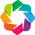

:Layout
   .Chord.Left_Hemisphere  :Chord   [source,target]   (value)
   .Chord.Right_Hemisphere :Chord   [source,target]   (value)

In [68]:
import holoviews as hv
from holoviews import opts
import pandas as pd

hv.extension('bokeh')

# 1. Helper function to prepare Chord data per hemisphere
def prepare_chord_data(df, hemi_label):
    # Filter for the specific hemisphere
    hemi_df = df[df['hemisphere'] == hemi_label]
    
    # We want to show how networks are 'confused'
    # For this example, we map relationships between Major Networks
    networks = hemi_df['major_network'].unique()
    
    data = []
    for source in networks:
        for target in networks:
            if source == target: continue
            
            # The 'value' represents the error/confusion weight
            # Here we use the mean task_rate as a proxy for confusion intensity
            val = hemi_df[hemi_df['major_network'] == source]['task_rate'].mean()
            data.append({'source': source, 'target': target, 'value': val})
            
    return pd.DataFrame(data)

# 2. Process LH and RH Data
chord_df_lh = prepare_chord_data(region_comparison, 'left')
chord_df_rh = prepare_chord_data(region_comparison, 'right')

# 3. Create Chords
chord_lh = hv.Chord(chord_df_lh, label='Left Hemisphere')
chord_rh = hv.Chord(chord_df_rh, label='Right Hemisphere')

# 4. Apply Academic Styling
chord_opts = opts.Chord(
    cmap='Category20', 
    edge_cmap='Category20', 
    edge_color=hv.dim('source').str(), 
    node_color=hv.dim('index').str(),
    labels='index', 
    label_text_font_size='9pt',
    node_size=12, 
    edge_alpha=0.5,
    width=600, height=600,
    title_format='{label}'
)

# Render side-by-side
layout = (chord_lh + chord_rh).opts(chord_opts)
hv.save(layout, 'hemisphere_confusion_chords.html')
layout

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
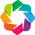

:Layout
   .Chord.Left_Hemisphere  :Chord   [source,target]   (value,type)
   .Chord.Right_Hemisphere :Chord   [source,target]   (value,type)

In [88]:
import holoviews as hv
from holoviews import opts
import pandas as pd

hv.extension('bokeh')

# 1. Helper function modified to INCLUDE within-network connections
def prepare_chord_data(df, hemi_label):
    hemi_df = df[df['hemisphere'] == hemi_label]
    networks = hemi_df['major_network'].unique()
    
    data = []
    for source in networks:
        for target in networks:
            # Removed the 'if source == target: continue' line
            
            # Calculate mean task_rate for the source network
            val = hemi_df[hemi_df['major_network'] == source]['task_rate'].mean()
            
            data.append({
                'source': source, 
                'target': target, 
                'value': val,
                'type': 'Within' if source == target else 'Across'
            })
            
    return pd.DataFrame(data)

# 2. Process LH and RH Data
chord_df_lh = prepare_chord_data(region_comparison, 'left')
chord_df_rh = prepare_chord_data(region_comparison, 'right')

# 3. Create Chords
chord_lh = hv.Chord(chord_df_lh, label='Left Hemisphere')
chord_rh = hv.Chord(chord_df_rh, label='Right Hemisphere')

# 4. Apply Academic Styling
chord_opts = opts.Chord(
    cmap='Category20', 
    edge_cmap='Category20', 
    edge_color=hv.dim('source').str(), 
    node_color=hv.dim('index').str(),
    labels='index', 
    label_text_font_size='9pt',
    node_size=12, 
    edge_alpha=0.5,
    width=600, height=600,
    title_format='{label}'
)

# Render side-by-side
layout = (chord_lh + chord_rh).opts(chord_opts)
hv.save(layout, 'hemisphere_confusion_with_internal.html')
layout

In [109]:
import plotly.graph_objects as go
import pandas as pd

# 1. Total Samples (Based on model evaluation context)
# For the Full (232) or Combined (L+R) models
TOTAL_SAMPLES_REST = 51968  
TOTAL_SAMPLES_TASK = 46400

# 2. Aggregate data by Network and Hemisphere
df_hemi = region_comparison.groupby(['major_network', 'hemisphere'])[['rest_errors', 'task_errors']].sum().reset_index()

# 3. Calculate Global Totals (Counts)
global_rest_total = region_comparison['rest_errors'].sum()
global_task_total = region_comparison['task_errors'].sum()

# 4. Calculate Global Error Percentages (Rates)
rest_error_pct = (global_rest_total / TOTAL_SAMPLES_REST) * 100
task_error_pct = (global_task_total / TOTAL_SAMPLES_TASK) * 100
diff_error_pct = task_error_pct - rest_error_pct

# 5. Calculate Relative Increase in Errors
net_increase_val = global_task_total - global_rest_total
# (Relative change in error volume)
net_increase_pct = (net_increase_val / global_rest_total * 100) if global_rest_total != 0 else 0

# Network-level totals for plotting
df_totals = df_hemi.groupby('major_network')[['rest_errors', 'task_errors']].sum().reset_index()
df_totals['task_pct'] = (df_totals['task_errors'] / global_task_total * 100).round(1)

# Sort networks by total task errors (descending)
sorted_networks = df_totals.sort_values('task_errors', ascending=False)['major_network'].tolist()

# 6. Create Plot Traces
fig = go.Figure()

def get_data(hemi, condition):
    merged = pd.merge(pd.DataFrame({'major_network': sorted_networks}), 
                      df_hemi[df_hemi['hemisphere'] == hemi], 
                      on='major_network', how='left').fillna(0)
    return merged[condition]

# Add Rest Errors (Stacked)
fig.add_trace(go.Bar(
    x=sorted_networks, y=get_data('left', 'rest_errors'),
    name='Rest: LH', offsetgroup=0, marker_color='rgba(31, 119, 180, 0.5)',
    legendgroup='Rest', legendgrouptitle_text="Resting State"
))
fig.add_trace(go.Bar(
    x=sorted_networks, y=get_data('right', 'rest_errors'),
    name='Rest: RH', offsetgroup=0, base=get_data('left', 'rest_errors'),
    marker_color='rgba(31, 119, 180, 0.9)',
    legendgroup='Rest'
))

# Add Task Errors (Stacked)
fig.add_trace(go.Bar(
    x=sorted_networks, y=get_data('left', 'task_errors'),
    name='Task: LH', offsetgroup=1, marker_color='rgba(255, 127, 14, 0.5)',
    legendgroup='Task', legendgrouptitle_text="Task-Based"
))
fig.add_trace(go.Bar(
    x=sorted_networks, y=get_data('right', 'task_errors'),
    name='Task: RH', offsetgroup=1, base=get_data('left', 'task_errors'),
    marker_color='rgba(255, 127, 14, 0.9)',
    legendgroup='Task'
))

# 7. Global Summary Annotation (Includes Global Error Percentages)
fig.add_annotation(
    xref="paper", yref="paper",
    x=0.98, y=0.98,
    text=(f"<b>GLOBAL PERFORMANCE SUMMARY</b><br>"
          f"Total Rest Errors: {int(global_rest_total)} (<b>{rest_error_pct:.2f}%</b>)<br>"
          f"Total Task Errors: {int(global_task_total)} (<b>{task_error_pct:.2f}%</b>)<br>"
          f"Difference in Error %: <b>{diff_error_pct:.2f}%</b><br>"
          f"Relative Error Increase: +{int(net_increase_val)} ({net_increase_pct:.1f}%)"),
    showarrow=False,
    align="right",
    bgcolor="rgba(255, 255, 255, 0.8)",
    bordercolor="black",
    borderwidth=1,
    borderpad=10,
    font=dict(size=12)
)

# 8. Network-level Annotations
for i, net in enumerate(sorted_networks):
    total_task = df_totals.loc[df_totals['major_network'] == net, 'task_errors'].values[0]
    pct = df_totals.loc[df_totals['major_network'] == net, 'task_pct'].values[0]
    total_rest = df_totals.loc[df_totals['major_network'] == net, 'rest_errors'].values[0]

    fig.add_annotation(
        x=net, y=total_rest, text=f"<b>{int(total_rest)}</b>",
        showarrow=False, yshift=10, xshift=-22, font=dict(size=10, color='rgb(31, 119, 180)')
    )
    fig.add_annotation(
        x=net, y=total_task, text=f"<b>{int(total_task)}</b><br>({pct}%)",
        showarrow=False, yshift=15, xshift=22, font=dict(size=11, color='rgb(255, 127, 14)')
    )

# 9. Final Layout
fig.update_layout(
    template='simple_white',
    title={
        'text': '<b>Absolute Errors by Hemisphere: Rest vs. Task</b><br><sup>Comparison of Error Rates and Raw Counts across Functional Networks</sup>',
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'font': dict(size=20)
    },
    xaxis_title='<b>Functional Network</b>',
    yaxis_title='<b>Number of Errors</b>',
    height=800, width=1350,
    barmode='group',
    margin=dict(t=160, b=100)
)

fig.update_yaxes(showgrid=True, gridcolor='lightgrey', range=[0, max(df_totals['task_errors']) * 1.3])
fig.update_xaxes(tickangle=45)

fig.show()

In [103]:
# percentage of errors per region
(6209-4372)

1837

In [104]:
1837 / 4372 * 100

42.01738334858188

In [107]:
4993 - 3943

1050

In [108]:
1050 / 3943 * 100

26.629469946741057